# Imports & Setup #

In [77]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Callable, Tuple, List
from dataclasses import dataclass

sys.path.append('../')

# Visualization Configuration #

In [78]:
@dataclass
class PlotParams:
    """
    Configuration for plot styling.
    """
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.5
    marker:     Optional[str] = None
    markersize: float = 1.0
    markevery:  int = 1000
    label:      str = ""
    alpha:      float = 1.0

In [79]:
class ResearchPlotter:
    """
    Class for generating publication-quality plots.
    """
    def __init__(self, title: str = None, xlabel: str = None, ylabel: str = None, figsize: tuple = (12, 7)):
        
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=18, pad=20)
        self.ax.set_xlabel(xlabel, fontsize=16, labelpad=15)
        self.ax.set_ylabel(ylabel, fontsize=16, labelpad=15)
        
        # Grid and ticks styling
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """
        Adds a single trajectory to the plot.
        """
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery,
            alpha       = params.alpha
        )

    def add_true_value(self, value: float, label: str = "True Value"):
        """
        Adds a horizontal line representing the ground truth.
        """
        self.ax.axhline(
            y=value, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=label,
            alpha=0.8,
            zorder=10
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """
        Finalizes the plot layout and displays it.
        """
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")

        plt.show()
        plt.close(self.fig)

# Math Functions #

In [80]:
def g_func_1d(x_vec: np.ndarray) -> np.ndarray:
    """Target function 1D: g(x) = x^6"""
    return x_vec**6

In [81]:
def g_func_nd(x_vec: np.ndarray) -> np.ndarray:
    """
    Target function ND: g(x) = (sum(x_i))^2
    Integration domain: [0, 1]^d
    """
    # x_vec shape: (N, d)
    # sum over last axis (d) -> (N,)
    return np.sum(x_vec, axis=1)**2

# Probability Distributions #

In [82]:
def uniform_pdf(x_vec: np.ndarray) -> np.ndarray:
    """Uniform PDF on [0, 1]^d: f(x) = 1"""
    # Volume of hypercube [0,1]^d is 1, so PDF is 1 everywhere inside
    return np.ones(x_vec.shape[0])

In [83]:
def uniform_sampler(n: int, dim: int) -> np.ndarray:
    """Sampler for Uniform distribution in d dimensions"""
    return np.random.uniform(low=0, high=1, size=(n, dim))

In [84]:
def importance_pdf_1d(x_vec: np.ndarray) -> np.ndarray:
    """Importance PDF 1D: f(x) = 4x^3"""
    return 4 * x_vec**3

In [85]:
def importance_sampler_1d(n: int, dim: int) -> np.ndarray:
    """
    Inverse Transform Sampler for f(x) = 4x^3 (1D only).
    """
    if dim != 1:
        raise ValueError("This importance sampler is only for 1D")
    u = np.random.uniform(low=0, high=1, size=(n, 1)) # Keep shape (n, 1)
    return u**(1/4)

# Monte Carlo Logic #

In [86]:
def run_single_simulation(n_max: int, dim: int, seed: int, g_func: Callable, pdf_func: Callable, sampler_func: Callable) -> np.ndarray:
    """
    Runs a single Monte Carlo simulation and returns the cumulative average trajectory.
    """
    # Set seed for this specific run
    np.random.seed(seed)
    
    # 1. Generate samples: (n_max, dim)
    xi_vec = sampler_func(n_max, dim)
    
    # Ensure 1D arrays are reshaped to (N, 1) if needed for consistency, though sampler should handle it
    if xi_vec.ndim == 1:
        xi_vec = xi_vec.reshape(-1, 1)

    # 2. Calculate weights: zeta = g(xi) / f(xi)
    g_vals = g_func(xi_vec)      # Returns (n_max,)
    pdf_vals = pdf_func(xi_vec)  # Returns (n_max,)
    
    zeta_vec = g_vals / pdf_vals
    
    # 3. Compute cumulative average
    cumulative_sum = np.cumsum(zeta_vec)
    n_vec = np.arange(1, n_max + 1)
    
    return cumulative_sum / n_vec

In [87]:
def run_averaged_simulation(n_max: int, dim: int, num_seeds: int, g_func: Callable, pdf_func: Callable, sampler_func: Callable) -> Tuple[np.ndarray, np.ndarray]:
    """
    Runs multiple Monte Carlo simulations and averages the results.
    """
    # Pre-allocate memory: (num_seeds, n_max)
    all_trajectories = np.zeros((num_seeds, n_max))
    
    print(f"Processing {num_seeds} seeds for {sampler_func.__name__} (Dim={dim})...")
    
    for i in range(num_seeds):
        current_seed = 42 + i
        all_trajectories[i, :] = run_single_simulation(n_max, dim, current_seed, g_func, pdf_func, sampler_func)
        
    # Calculate mean across seeds
    mean_trajectory = np.mean(all_trajectories, axis=0)
    n_vec = np.arange(1, n_max + 1)
    
    return n_vec, mean_trajectory

# Main Execution Block #

Processing 100 seeds for uniform_sampler (Dim=100)...
Figure saved to: monte_carlo_nd_convergence.pdf


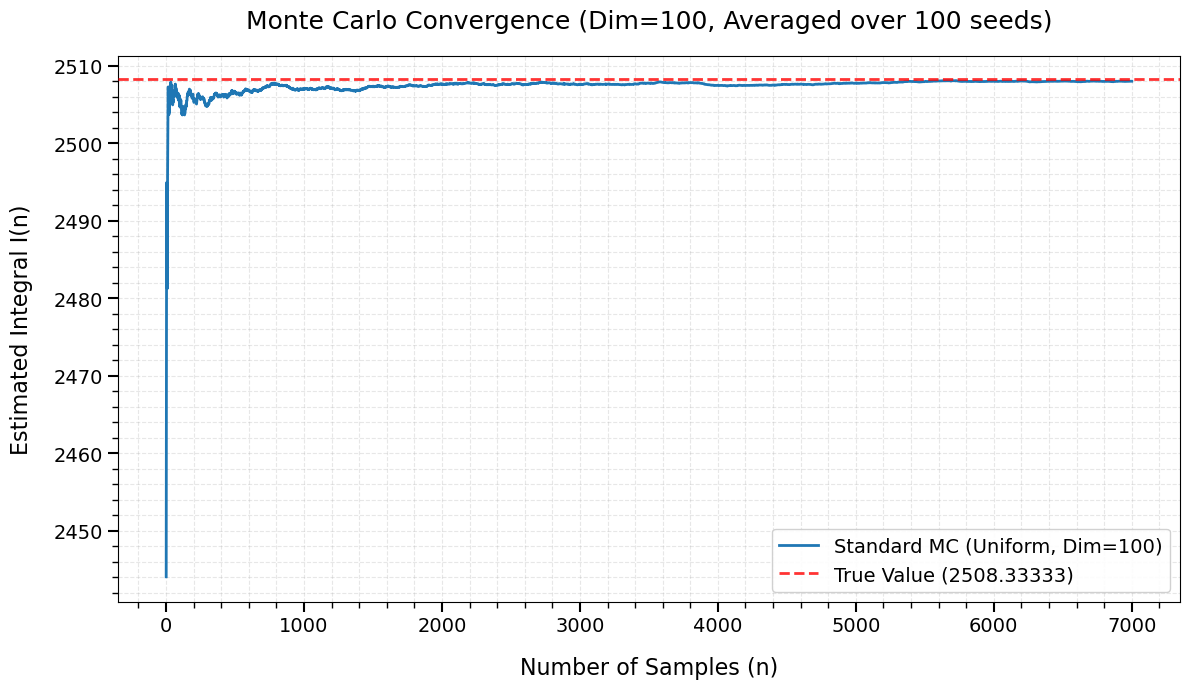


--- Final Statistics ---
Dimension: 100
True Value: 2508.33333333
Standard MC (Final): 2507.98526166 | Error: 3.48071671e-01


In [92]:
# --- Configuration ---

N_MAX = 7000
NUM_SEEDS = 100
DIM = 100  # Multidimensional case

TRUE_VALUE = DIM/12 + (DIM**2)/4

# --- Plotter Initialization ---
plotter = ResearchPlotter(
    title=f'Monte Carlo Convergence (Dim={DIM}, Averaged over {NUM_SEEDS} seeds)',
    xlabel='Number of Samples (n)',
    ylabel='Estimated Integral I(n)'
)

# --- Experiment: Standard Monte Carlo ND ---
n_vec, mean_uniform = run_averaged_simulation(
    N_MAX, DIM, NUM_SEEDS, g_func_nd, uniform_pdf, uniform_sampler
)

params_uniform = PlotParams(
    label=f'Standard MC (Uniform, Dim={DIM})',
    color='#1f77b4',
    linestyle='-',
    linewidth=2.0
)
plotter.add_plot(n_vec, mean_uniform, params_uniform)

# C = 0.005 * (DIM) # Heuristic scaling

# upper_bound = TRUE_VALUE + C / np.sqrt(n_vec)
# lower_bound = TRUE_VALUE - C / np.sqrt(n_vec)

# params_bound = PlotParams(
#     label=r'Convergence $\propto 1/\sqrt{N}$',
#     color='gray',
#     linestyle='--',
#     linewidth=1.5,
#     alpha=0.7
# )

# # Plotting only upper bound for clarity or both? Let's plot both as a filled area or lines
# plotter.add_plot(n_vec, upper_bound, params_bound)
# plotter.ax.plot(n_vec, lower_bound, linestyle='--', color='gray', linewidth=1.5, alpha=0.7)

# --- Finalize ---
plotter.add_true_value(TRUE_VALUE, label=f'True Value ({TRUE_VALUE:.5f})')
plotter.finalize_and_show(save_path='monte_carlo_nd_convergence.pdf')

# --- Print Stats ---
print("\n--- Final Statistics ---")
print(f"Dimension: {DIM}")
print(f"True Value: {TRUE_VALUE:.8f}")
print(f"Standard MC (Final): {mean_uniform[-1]:.8f} | Error: {abs(mean_uniform[-1] - TRUE_VALUE):.8e}")